## Step 1: Generating 2D Toy Dataset

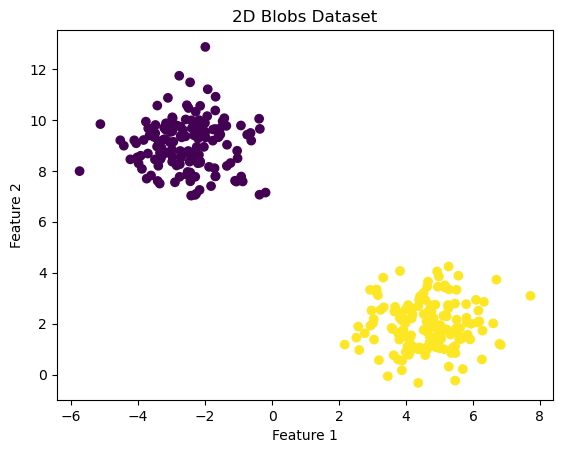

In [1]:
from sklearn.datasets import make_blobs
import matplotlib.pyplot as plt

#Generate 2D Blobs for 2 classes
X,y =  make_blobs(n_samples=300,centers=2,random_state=42)

plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.title('2D Blobs Dataset')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.show()

## Step 2: Converting data to Pytorch Tensors

In [2]:
import torch
from torch.utils.data import TensorDataset,DataLoader

#Convert features and labels to Pytorch tensors
X_tensor=torch.tensor(X,dtype=torch.float32)
y_tensor=torch.tensor(y,dtype=torch.int64)

#Create a dataset and data loader
dataset=TensorDataset(X_tensor,y_tensor)
data_loader=DataLoader(dataset,batch_size=32,shuffle=True)

## Step 3 : Training the Logistic Regression model

In [3]:
import torch.nn as nn
import torch.optim as optim

#Define the model
model = nn.Sequential(
    nn.Linear(2,1), #Two input features, one output
    nn.Sigmoid() #Sigmoid activation for binary classification
)

#Define the loss function and optimizer
criterion = nn.BCELoss() #Binary Cross Entropy Loss
optimizer=optim.SGD(model.parameters(),lr=0.01) #Stochastic Gradient Descent

#Training loop
for epoch in range(50):
    for X_batch,y_batch in data_loader:
        optimizer.zero_grad() #Zero the gradients
        op=model(X_batch).squeeze()
        loss=criterion(op,y_batch.float())
        loss.backward() #Backpropagation
        optimizer.step() #Step the optimizer

    #Print loss every 10 epochs
    if epoch%10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item()}')

Epoch 0, Loss: 0.9604291319847107
Epoch 10, Loss: 0.06894105672836304
Epoch 20, Loss: 0.05015561357140541
Epoch 30, Loss: 0.03331786394119263
Epoch 40, Loss: 0.04095885530114174


## Step 4: Visualizing the Decision Boundary

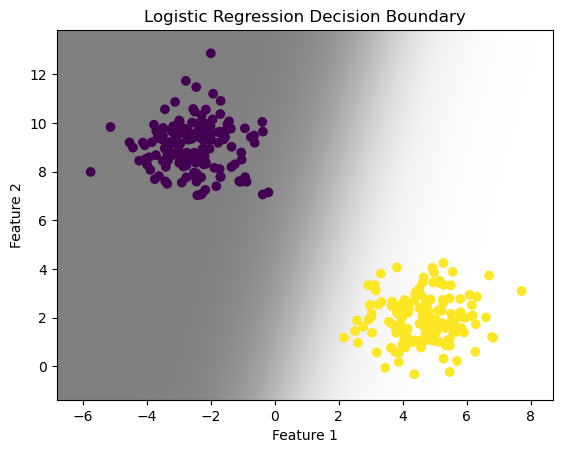

In [4]:
import numpy as np

#Generate grid of points
xx,yy=np.meshgrid(np.arange(X[:,0].min()-1, X[:,0].max()+1, 0.1),
                  np.arange(X[:,1].min()-1, X[:,1].max()+1, 0.1))

#Flatten grid
grid = torch.tensor(np.c_[xx.ravel(),yy.ravel()],dtype=torch.float32)

#Get model predictions
pred_grid=model(grid).detach().numpy().reshape(xx.shape)

#Plot decision boundary
plt.pcolormesh(xx,yy,pred_grid,cmap='gray',alpha=0.5)
plt.scatter(X[:,0],X[:,1],c=y,cmap='viridis')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('Logistic Regression Decision Boundary')
plt.show()